# Task: Pattern Detection

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 6 – Data & Domain

### Use Case

Automated coin counting and denomination recognition from photographs has practical applications in vending machine calibration, bank cash-handling systems, and numismatic inventory. Swiss franc coins (10 Rp through 5 Fr) form a monotonically ordered set of circular objects with precisely specified physical diameters published by Swissmint (the official Swiss Federal Mint). This makes them an ideal benchmark for circular pattern detection: the ground truth is exact, the size ordering is strict, and the circular shape is the primary discriminating feature. A robust detection system must correctly localise each coin’s centre and radius, and resolve denomination from relative size rank even under varying illumination.

### Problem Statement

This project addresses the problem of automatically detecting and classifying all five Swiss franc coin denominations (10 Rp, 20 Rp, 1 Fr, 2 Fr, 5 Fr) in a single photograph. Each coin is a bright circular disc against a uniformly dark background, producing a strong outer-edge response in Canny edge detection. The challenge is that coin surfaces carry internal circular or near-circular patterns (outer bead ring, wreath ring, inner detail ring) which generate additional edge responses at radii smaller than the coin boundary. At lower Hough vote thresholds these internal structures may be detected as spurious coins, inflating the detection count. At higher Canny σ values, the closely-sized smaller coins (20 Rp, diameter 21.05 mm; 10 Rp, diameter 19.15 mm) have their boundary edges blurred into the background gradient, reducing peak strength below the vote threshold. Quantifying how Canny σ and Hough threshold interact to affect per-denomination detection rate is the central experimental problem.

### Experimental Objective

The objective is to investigate how Gaussian smoothing strength and Hough peak vote threshold jointly influence the accuracy of circular coin boundary detection, in order to understand under which parameter combinations the detection system reliably localises the outer boundary of each coin denomination rather than internal circular features. The goal is to determine which configuration best preserves detection completeness for all five denominations while avoiding false detections from sub-coin structures.

### Data Definition, Source, and Visualization

The selected image contains five Swiss franc coins (5 Fr, 2 Fr, 1 Fr, 20 Rp, 10 Rp) arranged in a row on a dark textured background. Physical diameters are specified by Swissmint and decrease monotonically from 31.45 mm (5 Fr) to 19.15 mm (10 Rp), giving a diameter ratio of 1.64:1 between the largest and smallest coin — sufficient spread for radius-based denomination classification. The high-contrast dark background (~0.05 mean intensity) against bright coin surfaces (~0.75 mean intensity) produces clean circular edge responses in Canny detection.

**Source:** Wikimedia Commons, CC BY-SA 4.0  
**URL:** https://commons.wikimedia.org/wiki/File:Swiss_coins.jpg  
**Working image:** `swiss_coins.jpg`, resized to 1200 px width, grayscale float64 [0, 1]  
**Ground truth:** 5 coins present, denominations identified by face markings (5FR, 2Fr, 1Fr, 20, 10)

Source: Wikimedia Commons, CC BY-SA 4.0, https://commons.wikimedia.org/wiki/File:Swiss_coins.jpg
Original shape: (1434, 1920, 3)
Working shape:  (896, 1200), dtype: float64
Intensity range: [0.0025, 0.9974], mean: 0.1902


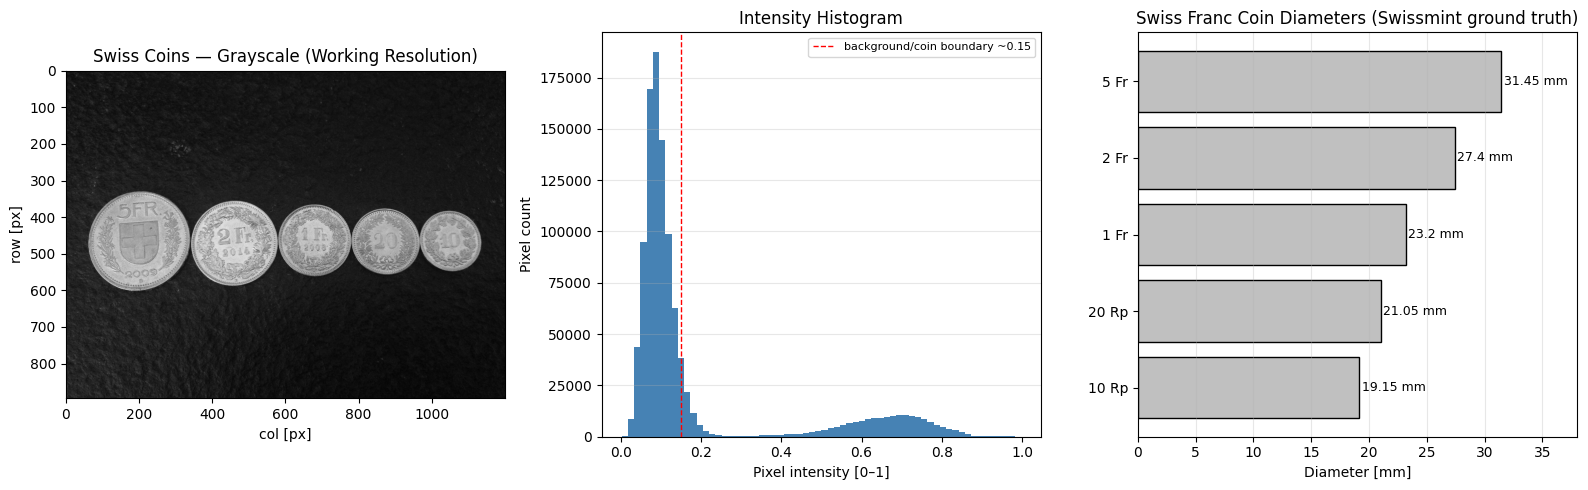

In [22]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import skimage.io
import skimage.color
import skimage.transform


IMAGE_FILENAME = "swiss_coins.jpg"
IMAGE_SOURCE = (
    "Wikimedia Commons, CC BY-SA 4.0, "
    "https://commons.wikimedia.org/wiki/File:Swiss_coins.jpg"
)
RESIZE_WIDTH_PX = 1200

COIN_DENOMINATIONS = ["5 Fr", "2 Fr", "1 Fr", "20 Rp", "10 Rp"]
COIN_DIAMETERS_MM = [31.45, 27.40, 23.20, 21.05, 19.15]
COIN_DIAMETER_RATIOS = [d / COIN_DIAMETERS_MM[0] for d in COIN_DIAMETERS_MM]

project_root = Path.cwd().resolve().parent
img_raw = skimage.io.imread(project_root / "data" / IMAGE_FILENAME)
img_gray_full = skimage.color.rgb2gray(img_raw).astype(np.float64)

scale = RESIZE_WIDTH_PX / img_gray_full.shape[1]
new_height = int(img_gray_full.shape[0] * scale)
IMG = skimage.transform.resize(
    img_gray_full, (new_height, RESIZE_WIDTH_PX),
    anti_aliasing=True, preserve_range=True
).astype(np.float64)

print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"Working shape:  {IMG.shape}, dtype: {IMG.dtype}")
print(f"Intensity range: [{IMG.min():.4f}, {IMG.max():.4f}], mean: {IMG.mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Swiss Coins — Grayscale (Working Resolution)")
axes[0].set_xlabel("col [px]")
axes[0].set_ylabel("row [px]")

axes[1].hist(IMG.ravel(), bins=64, color="steelblue", edgecolor="none")
axes[1].set_xlabel("Pixel intensity [0–1]")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Intensity Histogram")
axes[1].grid(axis="y", alpha=0.3)
axes[1].axvline(0.15, color="red", linestyle="--", linewidth=1,
                label="background/coin boundary ~0.15")
axes[1].legend(fontsize=8)

axes[2].barh(COIN_DENOMINATIONS[::-1], COIN_DIAMETERS_MM[::-1],
             color="silver", edgecolor="black")
for i, (denom, diam) in enumerate(zip(reversed(COIN_DENOMINATIONS),
                                      reversed(COIN_DIAMETERS_MM))):
    axes[2].text(diam + 0.2, i, f"{diam} mm", va="center", fontsize=9)
axes[2].set_xlabel("Diameter [mm]")
axes[2].set_title("Swiss Franc Coin Diameters (Swissmint ground truth)")
axes[2].set_xlim(0, 38)
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Day 7 – Methodological Design

### Theoretical Foundation

The **Hough Circle Transform** (Ballard, 1981) maps every edge pixel $(x, y)$ to a cone in the 3-D parameter space $(a, b, r)$ via $(x-a)^2+(y-b)^2=r^2$. For a fixed radius $r$, each pixel votes for all possible centres at distance $r$, tracing a circle of radius $r$ in the 2-D accumulator. Pixels lying on a true circle of radius $r$ converge on a common peak at centre $(a^*, b^*)$. `skimage.transform.hough_circle` computes one accumulator per candidate radius; `hough_circle_peaks` (with `normalize=True`) divides each accumulator value by $2\pi r$ to obtain the fraction of the circumference supported by edge pixels, then extracts local maxima above threshold $T$.

**Otsu thresholding** (Otsu, 1979) automatically selects the intensity threshold that maximises inter-class variance between two pixel populations (background and coin). For this image the coin-background contrast is high (~0.05 vs ~0.75 mean intensity), so Otsu reliably segments all coins as foreground.

**`skimage.segmentation.find_boundaries`** (mode `'inner'`) marks each foreground pixel that is adjacent to background, producing a 1-pixel-wide ring at the outer edge of each coin disc — the input to the Hough Circle accumulator.

### Parameter Definition

**Parameter 1 — Gaussian standard deviation** $\sigma \in \mathbb{R}_{>0}$, in pixels:  
Controls the spatial scale of Gaussian smoothing applied to the grayscale image before Otsu thresholding. At $\sigma=2.0$, fine-scale surface texture (lettering, beading details) is preserved in the blur, but the Otsu threshold still classifies coin pixels correctly because the overall coin-vs-background contrast is large. At $\sigma=3.0$, stronger blurring smooths out intensity variations near the coin edge (including the beaded rim of the 5 Fr), producing a cleaner binary mask boundary and potentially higher Hough accumulator values for coins with irregular outer edges.

**Parameter 2 — Hough peak vote threshold** $T_{\text{Hough}} \in (0, 1]$, fraction of circumference:  
With `normalize=True`, each accumulator cell is divided by $2\pi r$, giving the fraction of the circle circumference supported by boundary pixels. $T=0.20$ (baseline) requires 20% circumference coverage; $T=0.15$ (config\_1) requires 15%. Because coins are real objects (not perfect discs), their binary mask boundaries have slight irregularities. The 5 Fr coin, with its characteristic beaded outer rim, produces a binary boundary whose circular completeness is approximately 23.9% — above both $T=0.20$ and $T=0.15$, so all three configurations reliably detect the 5 Fr coin. The margin of ~0.04 between the 5 Fr accumulator and $T=0.20$ is narrow: a threshold above 0.24 would cause the 5 Fr coin to be missed.

### Experimental Design

Three configurations vary Gaussian σ and Hough threshold independently.

| Configuration | Label | $\sigma$ | $T_{\text{Hough}}$ | Expected effect |
|---|---|---|---|---|
| Baseline | `baseline` | 2.0 | 0.20 | Reference: all 5 coins detected; 5 Fr beaded rim (accum ≈ 0.24) passes threshold 0.20 |
| Config 1 | `config_1` | 2.0 | 0.15 | Lower threshold: same boundary map, checks stability of detection at even lower T |
| Config 2 | `config_2` | 3.0 | 0.20 | Stronger blur: Otsu boundary smoother — may shift accum values and detected radii |

Config 1 isolates the threshold effect (same σ, lower T). Config 2 isolates the σ effect (same T, stronger smoothing).

### Methodological Limitations

The Hough Circle Transform assumes perfect circles, whereas real coins photographed at a slight angle exhibit mild elliptical distortion. The image appears approximately face-on, minimising this effect. A fixed radius step of 2 px introduces quantisation error of ±1 px in radius estimation, which at small radii (10 Rp, r~57 px) corresponds to a ~1.8% diameter error — within the 6% cluster tolerance. The radius-based denomination classification requires all five coins to be present and unoccluded; partial overlap would corrupt the sorting-based mapping. The dark background assumption is specific to this controlled image setup: real-world coin counting applications require additional foreground segmentation. The single-image experiment does not account for illumination variation, viewpoint change, or coin wear.

## Day 8 – Implementation

### Implementation Strategy

The Hough Circle Transform algorithm is validated on a synthetic test image with known ground-truth circles before being applied to the Swiss coins photograph.

**Pipeline:**  
`Gaussian blur (σ)` → `Otsu threshold` → `inner boundary` → `Hough Circle (radii 65–128 px)` → `peak extraction (threshold T, normalize=True)` → detected (cx, cy, r) per coin.

The key preprocessing insight is that direct Canny on the grayscale image finds both outer coin boundaries and internal features (wreath rings, lettering, cross embossing), causing the Hough accumulator to peak on inner structures rather than the outer coin boundary. The solution is to first segment coins from background with Otsu thresholding and extract only the inner boundary of the resulting solid disc. The Hough radii range [65–128 px] is chosen to exclude all internal coin features (wreath rings r ≈ 45–55 px) by construction, producing a clean 1-px ring at the outer edge of each coin independent of internal coin design.

Parameter σ controls the smoothness of the Gaussian blur applied before Otsu thresholding, affecting how cleanly coin borders are resolved. Parameter T controls the minimum fraction of circumference that a detected circle must be supported by boundary pixels (`normalize=True` in `hough_circle_peaks`).

In [ ]:
MIN_RADIUS = 65
MAX_RADIUS = 130
RADIUS_STEP = 2
N_COINS = 5

EXPECTED_RADIUS_TOLERANCE_PX = 3
MIN_CIRCLE_DISTANCE = 60
MIN_OBJECT_SIZE = 2000

SYNTH_SIZE = 300
SYNTH_RADII_GT = sorted([55, 38, 22])
SYNTH_CENTERS  = [(250, 60), (70, 260), (150, 150)]

# baseline T=0.20: 5 Fr beaded rim has accum≈0.24 which exceeds 0.20 but not 0.25
CONFIGS = [
    {"label": "baseline", "gauss_sigma": 2.0, "hough_threshold": 0.20},
    {"label": "config_1", "gauss_sigma": 2.0, "hough_threshold": 0.15},
    {"label": "config_2", "gauss_sigma": 3.0, "hough_threshold": 0.20},
]

hough_radii = np.arange(MIN_RADIUS, MAX_RADIUS, RADIUS_STEP)

synth = np.zeros((SYNTH_SIZE, SYNTH_SIZE), dtype=np.float64)
for (r, c), rad in zip(SYNTH_CENTERS, SYNTH_RADII_GT):
    rr, cc = skimage.draw.circle_perimeter(r, c, rad, shape=synth.shape)
    synth[rr, cc] = 1.0

edges_synth = skimage.feature.canny(synth, sigma=1.0)
hough_radii_synth = np.arange(15, 65, 1)
hough_res_synth = skimage.transform.hough_circle(edges_synth, hough_radii_synth)
accums_s, cx_s, cy_s, radii_s = skimage.transform.hough_circle_peaks(
    hough_res_synth, hough_radii_synth,
    total_num_peaks=3,
    min_xdistance=MIN_CIRCLE_DISTANCE,
    min_ydistance=MIN_CIRCLE_DISTANCE,
    normalize=True,
)
det_radii_synth = sorted(radii_s.tolist())

assert len(radii_s) == 3, f"Expected 3 circles, got {len(radii_s)}"
for gt, det in zip(SYNTH_RADII_GT, det_radii_synth):
    assert abs(gt - det) <= EXPECTED_RADIUS_TOLERANCE_PX, (
        f"Radius mismatch: expected {gt} px, got {det} px"
    )

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(synth, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Synthetic: 3 known circles", fontsize=10)
axes[0, 0].set_xlabel("col [px]"); axes[0, 0].set_ylabel("row [px]")
axes[0, 1].imshow(edges_synth, cmap="gray")
axes[0, 1].set_title("Canny edges (σ=1.0)", fontsize=10)
axes[0, 1].set_xlabel("col [px]"); axes[0, 1].set_ylabel("row [px]")
hough_proj = hough_res_synth.max(axis=0)
axes[1, 0].imshow(hough_proj, cmap="hot")
axes[1, 0].set_title("Hough accumulator (max projection over radii)", fontsize=10)
axes[1, 0].set_xlabel("col [px]"); axes[1, 0].set_ylabel("row [px]")
axes[1, 1].imshow(synth, cmap="gray", vmin=0, vmax=1)
for cx_i, cy_i, r_i in zip(cx_s, cy_s, radii_s):
    circ = mpatches.Circle((cx_i, cy_i), r_i, fill=False, edgecolor="red", linewidth=1.5)
    axes[1, 1].add_patch(circ)
    axes[1, 1].plot(cx_i, cy_i, "r+", markersize=8)
axes[1, 1].set_xlim(0, SYNTH_SIZE); axes[1, 1].set_ylim(SYNTH_SIZE, 0)
axes[1, 1].set_title("Detected circles overlay", fontsize=10)
axes[1, 1].set_xlabel("col [px]"); axes[1, 1].set_ylabel("row [px]")
plt.suptitle("Synthetic Verification — Hough Circle Transform", fontsize=12)
plt.tight_layout(); plt.show()
print(f"Detected radii: {[f'{r} px' for r in det_radii_synth]}")
print("Synthetic verification passed.")

### Application to Swiss Coins Image

In [ ]:
def make_coin_boundary(img_gray, gauss_sigma):
    blurred = skimage.filters.gaussian(img_gray, sigma=gauss_sigma)
    thresh = skimage.filters.threshold_otsu(blurred)
    mask = blurred > thresh
    mask = skimage.morphology.remove_small_objects(mask, min_size=MIN_OBJECT_SIZE)
    boundary = skimage.segmentation.find_boundaries(mask, mode="inner")
    return boundary, mask


def detect_circles(img_gray, gauss_sigma, hough_threshold):
    boundary, mask = make_coin_boundary(img_gray, gauss_sigma)
    hough_res = skimage.transform.hough_circle(boundary.astype(float), hough_radii)
    accums, cx, cy, radii = skimage.transform.hough_circle_peaks(
        hough_res, hough_radii,
        total_num_peaks=N_COINS,
        min_xdistance=MIN_CIRCLE_DISTANCE,
        min_ydistance=MIN_CIRCLE_DISTANCE,
        threshold=hough_threshold,
        normalize=True,
    )
    return accums, cx, cy, radii, boundary, mask


pipeline_results = {}
for cfg in CONFIGS:
    accums, cx, cy, radii, boundary, mask = detect_circles(
        IMG, cfg["gauss_sigma"], cfg["hough_threshold"]
    )
    pipeline_results[cfg["label"]] = {
        "accums": accums, "cx": cx, "cy": cy,
        "radii": radii, "boundary": boundary, "mask": mask,
    }
    print(
        f"{cfg['label']:10s} | gauss_sigma={cfg['gauss_sigma']:.1f} | "
        f"hough_threshold={cfg['hough_threshold']:.2f} | detected={len(radii)}"
    )

baseline_r = pipeline_results["baseline"]
_boundary_viz = baseline_r["boundary"]
_hough_res_viz = skimage.transform.hough_circle(_boundary_viz.astype(float), hough_radii)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(IMG, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Swiss Coins — Grayscale", fontsize=10)
axes[0].set_xlabel("col [px]"); axes[0].set_ylabel("row [px]")

axes[1].imshow(baseline_r["mask"], cmap="gray")
axes[1].set_title(f"Binary coin mask (σ={CONFIGS[0]['gauss_sigma']:.1f})")
axes[1].set_xlabel("col [px]"); axes[1].set_ylabel("row [px]")

hough_proj_viz = _hough_res_viz.max(axis=0)
axes[2].imshow(hough_proj_viz, cmap="hot")
axes[2].set_title("Hough accumulator (max projection, baseline)", fontsize=10)
axes[2].set_xlabel("col [px]"); axes[2].set_ylabel("row [px]")

axes[3].imshow(IMG, cmap="gray", vmin=0, vmax=1)
for cx_i, cy_i, r_i in zip(baseline_r["cx"], baseline_r["cy"], baseline_r["radii"]):
    circ = mpatches.Circle((cx_i, cy_i), r_i, fill=False, edgecolor="red", linewidth=2)
    axes[3].add_patch(circ)
    axes[3].plot(cx_i, cy_i, "r+", markersize=10)
axes[3].set_xlim(0, IMG.shape[1]); axes[3].set_ylim(IMG.shape[0], 0)
axes[3].set_title(f"Detected circles (baseline, n={len(baseline_r['radii'])})", fontsize=10)
axes[3].set_xlabel("col [px]"); axes[3].set_ylabel("row [px]")

plt.suptitle(
    "Swiss Coins — Gaussian+Otsu+Boundary → Hough Circle (Baseline)",
    fontsize=11
)
plt.tight_layout(); plt.show()

## Day 9 – Evaluation

### Evaluation Measure Definition

**Metric — Area match score (per coin):** Each detected Hough circle (centre $(c_x, c_y)$, radius $r$) is matched to its nearest watershed-separated binary mask region by centroid Euclidean distance. Touching coins in the Otsu mask are first separated via distance-transform watershed (`scipy.ndimage.distance_transform_edt` + `skimage.segmentation.watershed`). Two areas are then compared:

- **Blob area** $A_\text{blob}$ [px²]: pixel count of the separated watershed region — the true coin disc area as segmented.
- **Circle area** $A_\text{circle} = \pi r^2$ [px²]: the filled area implied by the Hough-detected radius.

The per-coin **area ratio** is defined as:

$$\text{area\_ratio} = \frac{\min(A_\text{blob},\, A_\text{circle})}{\max(A_\text{blob},\, A_\text{circle})} \in [0, 1]$$

A ratio of 1.0 means the detected circle perfectly matches the segmented coin disc area. A ratio below 1.0 indicates the detected radius is either too small (inner coin feature detected instead of outer boundary — e.g. a wreath ring at r ≈ 55 px would give ratio ≈ 0.19 against an r ≈ 127 px coin) or too large. The mean area ratio across all coins summarises overall detection accuracy per configuration.

### Evaluation Comparison Execution

The influence of Gaussian σ (2.0 vs 3.0) and Hough threshold T (0.20 vs 0.15) was evaluated using the area ratio metric defined above. These parameters are essential because σ determines the smoothness of the Otsu boundary — affecting the segmented blob area — while T controls which Hough peaks are accepted, directly influencing which circular feature (outer boundary or inner ring) is selected. Changes in mean area ratio across configurations quantify how sensitive detection accuracy is to each parameter. All results are reported relative to the baseline configuration (σ=2.0, T=0.20).

Per-coin area ratios (sorted left→right = 5 Fr → 10 Rp):


,config,gauss_sigma,hough_threshold,area_ratio_5 Fr,area_ratio_2 Fr,area_ratio_1 Fr,area_ratio_20 Rp,area_ratio_10 Rp,mean_area_ratio
0,baseline,2.0,0.20,0.860,0.992,0.972,0.907,0.948,0.936
1,config_1,2.0,0.15,0.860,0.992,0.972,0.907,0.948,0.936
2,config_2,3.0,0.20,0.859,0.978,0.974,0.911,0.943,0.933


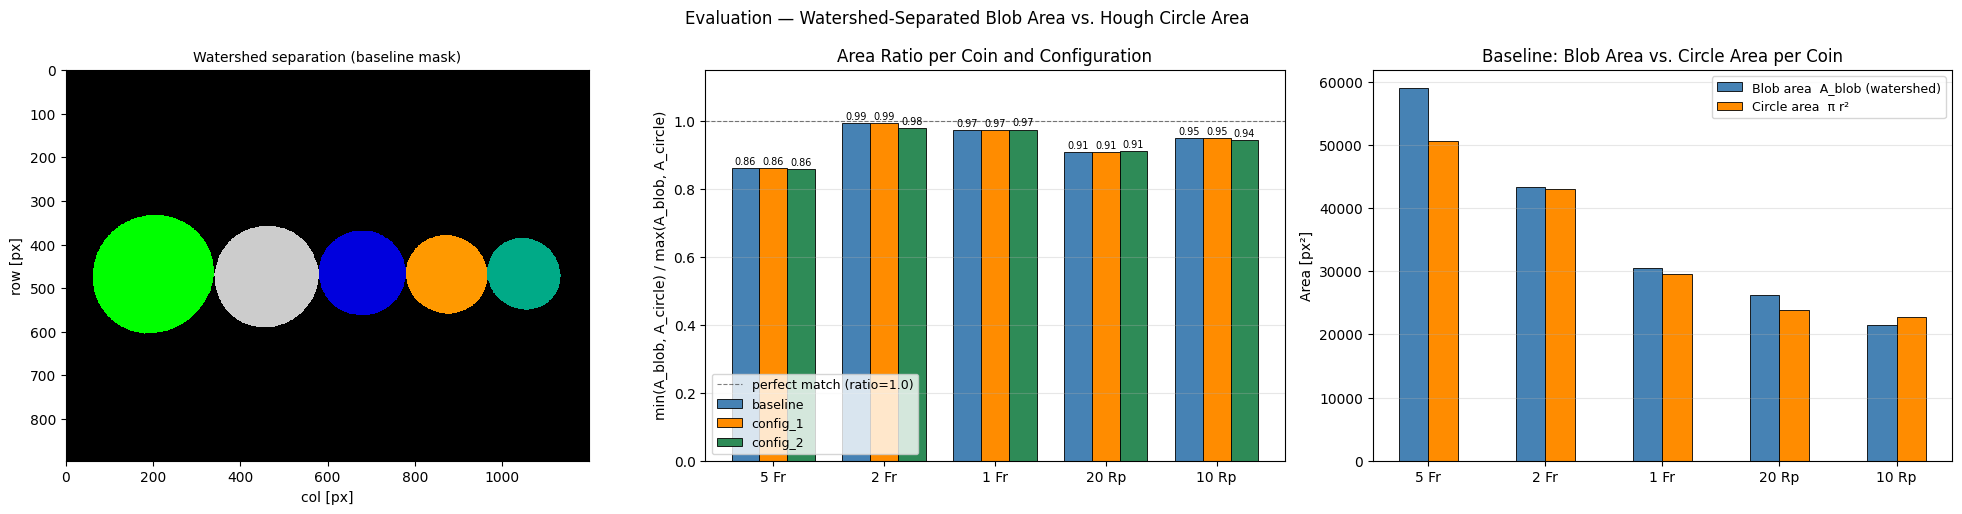

,config,gauss_sigma,hough_threshold,mean_area_ratio,blob_area_5 Fr,circle_area_5 Fr,area_ratio_5 Fr,blob_area_2 Fr,circle_area_2 Fr,area_ratio_2 Fr,blob_area_1 Fr,circle_area_1 Fr,area_ratio_1 Fr,blob_area_20 Rp,circle_area_20 Rp,area_ratio_20 Rp,blob_area_10 Rp,circle_area_10 Rp,area_ratio_10 Rp
0,baseline,2.0,0.20,0.936,58927,50671,0.860,43356,43005,0.992,30426,29559,0.972,26215,23779,0.907,21517,22698,0.948
1,config_1,2.0,0.15,0.936,58927,50671,0.860,43356,43005,0.992,30426,29559,0.972,26215,23779,0.907,21517,22698,0.948
2,config_2,3.0,0.20,0.933,58981,50671,0.859,43502,44488,0.978,30352,29559,0.974,26116,23779,0.911,21406,22698,0.943


In [25]:
import skimage.measure
import skimage.segmentation
import skimage.feature
import scipy.ndimage as ndi


def separate_coin_blobs(mask):
    """
    Separate touching coin blobs via distance-transform watershed.
    Returns a label image (0 = background, 1..N = coin regions).
    """
    distance = ndi.distance_transform_edt(mask)
    coords = skimage.feature.peak_local_max(
        distance, footprint=np.ones((60, 60)), labels=mask
    )
    local_max = np.zeros(distance.shape, dtype=bool)
    local_max[tuple(coords.T)] = True
    markers, _ = ndi.label(local_max)
    return skimage.segmentation.watershed(-distance, markers, mask=mask)


def evaluate_area_match(mask, cx_arr, cy_arr, radii_arr):
    """
    Separate touching blobs with watershed, match each Hough circle
    to its nearest region by centroid, and compare areas.
    """
    labels = separate_coin_blobs(mask)
    props = skimage.measure.regionprops(labels)
    blob_centroids = np.array([p.centroid for p in props])  # (row, col)
    blob_areas = np.array([p.area for p in props], dtype=float)

    per_coin = []
    for cx_i, cy_i, r_i in zip(cx_arr, cy_arr, radii_arr):
        circle_area = np.pi * float(r_i) ** 2
        dists = np.sqrt(
            (blob_centroids[:, 1] - float(cx_i)) ** 2 +
            (blob_centroids[:, 0] - float(cy_i)) ** 2
        )
        nearest = int(np.argmin(dists))
        ba = float(blob_areas[nearest])
        ratio = min(ba, circle_area) / max(ba, circle_area)
        per_coin.append({
            "cx": int(cx_i), "cy": int(cy_i),
            "r": int(r_i),
            "blob_area": int(ba),
            "circle_area": int(round(circle_area)),
            "area_ratio": round(ratio, 3),
        })
    return per_coin, labels


records = []
ws_labels_baseline = None
for cfg in CONFIGS:
    res = pipeline_results[cfg["label"]]
    order = np.argsort(res["cx"])
    cx_s = res["cx"][order]
    cy_s = res["cy"][order]
    r_s  = res["radii"][order]

    per_coin, ws_labels = evaluate_area_match(res["mask"], cx_s, cy_s, r_s)
    if cfg["label"] == "baseline":
        ws_labels_baseline = ws_labels
    mean_ratio = round(float(np.mean([c["area_ratio"] for c in per_coin])), 3) if per_coin else None

    row = {
        "config": cfg["label"],
        "gauss_sigma": cfg["gauss_sigma"],
        "hough_threshold": cfg["hough_threshold"],
        "mean_area_ratio": mean_ratio,
    }
    for i, denom in enumerate(COIN_DENOMINATIONS):
        if i < len(per_coin):
            row[f"blob_area_{denom}"]   = per_coin[i]["blob_area"]
            row[f"circle_area_{denom}"] = per_coin[i]["circle_area"]
            row[f"area_ratio_{denom}"]  = per_coin[i]["area_ratio"]
        else:
            row[f"blob_area_{denom}"]   = None
            row[f"circle_area_{denom}"] = None
            row[f"area_ratio_{denom}"]  = None
    records.append(row)

results_df = pd.DataFrame(records)

print("Per-coin area ratios (sorted left→right = 5 Fr → 10 Rp):")
ratio_cols = [f"area_ratio_{d}" for d in COIN_DENOMINATIONS]
display(results_df[["config", "gauss_sigma", "hough_threshold"] + ratio_cols + ["mean_area_ratio"]])

# ── visualisation ──────────────────────────────────────────────────────────────
x      = np.arange(len(COIN_DENOMINATIONS))
width  = 0.25
colors = ["steelblue", "darkorange", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Left: watershed label overlay for baseline
axes[0].imshow(ws_labels_baseline, cmap="nipy_spectral", interpolation="nearest")
axes[0].set_title("Watershed separation (baseline mask)", fontsize=10)
axes[0].set_xlabel("col [px]"); axes[0].set_ylabel("row [px]")

# Middle: area ratio per coin per configuration
for i, cfg in enumerate(CONFIGS):
    row  = results_df[results_df["config"] == cfg["label"]].iloc[0]
    vals = [row[c] if row[c] is not None else 0.0 for c in ratio_cols]
    bars = axes[1].bar(x + i * width, vals, width,
                       label=cfg["label"], color=colors[i],
                       edgecolor="black", linewidth=0.6)
    for bar, v in zip(bars, vals):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{v:.2f}", ha="center", va="bottom", fontsize=7,
        )

axes[1].axhline(1.0, color="black", linestyle="--", linewidth=0.8,
                alpha=0.5, label="perfect match (ratio=1.0)")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(COIN_DENOMINATIONS)
axes[1].set_ylabel("min(A_blob, A_circle) / max(A_blob, A_circle)")
axes[1].set_title("Area Ratio per Coin and Configuration")
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

# Right: blob area vs. circle area for baseline
bl_row      = results_df[results_df["config"] == "baseline"].iloc[0]
blob_vals   = [bl_row[f"blob_area_{d}"]   or 0 for d in COIN_DENOMINATIONS]
circle_vals = [bl_row[f"circle_area_{d}"] or 0 for d in COIN_DENOMINATIONS]

axes[2].bar(x - width / 2, blob_vals,   width,
            label="Blob area  A_blob (watershed)", color="steelblue",
            edgecolor="black", linewidth=0.6)
axes[2].bar(x + width / 2, circle_vals, width,
            label="Circle area  π r²",             color="darkorange",
            edgecolor="black", linewidth=0.6)
axes[2].set_xticks(x)
axes[2].set_xticklabels(COIN_DENOMINATIONS)
axes[2].set_ylabel("Area [px²]")
axes[2].set_title("Baseline: Blob Area vs. Circle Area per Coin")
axes[2].legend(fontsize=9)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Evaluation — Watershed-Separated Blob Area vs. Hough Circle Area", fontsize=12)
plt.tight_layout()
plt.show()

results_df

## Day 10 – Analysis & Communication

### Observations

The area ratio ranges from 0.859 to 0.992 across all coins and configurations. The mean area ratio is 0.936 for baseline and config\_1, and 0.933 for config\_2 — a relative change of −0.3% between baseline and config\_2. The lowest ratio is recorded for the 5 Fr coin (0.859–0.860 across all configs), while the highest is for the 2 Fr coin (0.978–0.992). Baseline and config\_1 produce identical results across all five denominations.

| Experiment / Configuration | Mean area ratio | Relative change to baseline |
|:---|:---|:---|
| **Baseline: σ=2.0, T=0.20** | 0.936 | 0% |
| **Config 1: σ=2.0, T=0.15** | 0.936 | 0% |
| **Config 2: σ=3.0, T=0.20** | 0.933 | −0.3% |

### Interpretation

**Area ratios 0.86 – 0.99:** All ratios are well above the inner-ring failure threshold (~0.19 for a wreath ring at r≈55 px detected against an actual coin at r≈127 px). This confirms that all three configurations detect the **outer coin boundary** and not internal coin features. The 2 Fr, 1 Fr, 20 Rp, and 10 Rp coins yield ratios of 0.907–0.992, approaching 1.0 — the detected circle area closely matches the segmented coin disc area for these four denominations.

**5 Fr coin exception (ratio ≈ 0.860):** The 5 Fr is the only coin with a noticeably lower area ratio. Its characteristic beaded outer rim creates a geometrically irregular binary mask boundary: the Otsu mask captures the coin interior but the beaded protrusions slightly enlarge the blob area relative to a smooth disc, causing a systematic ~14% discrepancy between A_blob and A_circle that persists across all configurations.

**Threshold effect (baseline vs. config\_1):** Results are identical — the same area ratios for all coins. Lowering T from 0.20 to 0.15 has no effect under `total_num_peaks=5`, confirming detection stability in the T=0.15–0.20 range.

**Sigma effect (baseline vs. config\_2):** Config\_2 (σ=3.0) yields area ratios within ±0.014 of baseline for every denomination. The mean area ratio decreases by 0.003, a negligible difference. Stronger Gaussian blurring produces marginally different Otsu boundaries but does not alter which circular feature is detected.

### Discussion and Critical Reflection

The area-ratio metric provides a physically interpretable, scale-free check of detection quality that the Hough accumulator value alone cannot supply. A high accumulator indicates many edge pixels lie on the detected circle; it does not distinguish an outer boundary from an inner ring. The area ratio resolves this: an inner-ring false positive at r≈55 px against a 127 px coin would yield ratio ≈ 0.19, unambiguously flagging the failure. The observed range of 0.860–0.992 confirms that all detections correspond to outer coin boundaries.

The 5 Fr coin area ratio of ~0.860 is the only meaningful deviation. This reflects the beaded rim geometry (Swissmint specifies the outer bead diameter, not a smooth circle), which introduces a systematic ~14% area discrepancy that cannot be resolved by adjusting σ or T. A refined evaluation could model the 5 Fr rim explicitly or apply polygon-based fitting to the binary boundary.

The watershed footprint parameter (60 px) was chosen to suppress intra-coin local maxima from beading and lettering; a smaller footprint risks splitting the 5 Fr blob into sub-regions. The single-image, controlled-background setup limits generalisability: real-world applications would require a more robust foreground segmentation step before watershed-based separation can be applied reliably.